In [2]:
from quantile_network import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# import tables # Doesn't seem to want to import

## Data Processing

In [3]:
dfs = []
for i in range(1,11):
    df = pd.read_json(f"../data/ml_data_{i}.json").set_index('ievt_n')
    dfs.append(df)
df_data = pd.concat(dfs)
df_data

,Es,AoEs,E0,dt0,E1,dt1,E2,dt2,E3,dt3,Esum
ievt_n,,,,,,,,,,,
360003,2354.439453,0.641558,940.579942,1574.577946,651.912590,1572.347826,307.433960,1582.817392,115.876126,1712.930667,2352.960288
360004,582.839111,0.479840,204.494507,1731.669068,200.974736,1660.409688,105.445949,1744.875713,72.272930,1669.453151,583.188122
360005,555.460754,0.724179,183.029281,1739.242719,154.452500,1702.582090,152.529828,1748.431137,39.980146,1716.992048,554.852811
360007,2129.252686,0.673952,1606.274136,1831.357694,196.149013,1755.611072,183.698388,1733.071785,120.881658,1730.347510,2129.291704
360008,2891.735840,0.703362,1855.270891,1558.411382,554.174998,1537.181731,211.470209,1606.489368,205.058466,1545.370130,2890.459665
...,...,...,...,...,...,...,...,...,...,...,...
33923,583.609558,0.790431,303.190247,1523.848160,115.252755,1516.271254,103.784227,1528.513111,60.960893,1531.853479,583.188122
33924,2853.392090,0.480213,1468.138792,1604.459594,345.460381,1775.509748,237.476614,1629.465514,204.449208,1732.692377,2851.721384
33927,2803.032715,0.738291,1157.217605,1764.436860,834.124129,1740.112583,346.690145,1762.492599,212.531360,1814.526581,2803.024643


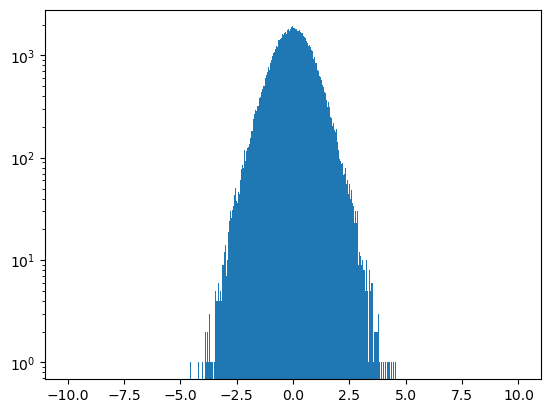

In [13]:
Es = df_data.Es
Esum = df_data.Esum
plt.figure()
_ = plt.hist(Es-Esum, bins=1000, range=(-10,10))
plt.yscale('log')

In [14]:
xdata = df_data[['E0', 'E1', 'Esum', 'dt0', 'dt1']].to_numpy()
xdata

array([[ 940.57994199,  651.91259001, 2352.96028788, 1574.57794571,
        1572.34782614],
       [ 204.49450712,  200.97473611,  583.18812203, 1731.66906849,
        1660.40968811],
       [ 183.02928074,  154.45250018,  554.85281124, 1739.24271949,
        1702.58208997],
       ...,
       [1157.21760505,  834.12412942, 2803.02464266, 1764.43685979,
        1740.11258326],
       [ 979.81588657,  873.6798693 , 2693.13920524, 1641.66878666,
        1696.98710701],
       [ 543.92365523,   92.54995093,  745.40807001, 1787.77632015,
        1782.34461687]])

In [15]:
ydata = df_data[['Es', 'AoEs']].to_numpy()
ydata

array([[2.35443945e+03, 6.41558230e-01],
       [5.82839111e+02, 4.79839891e-01],
       [5.55460754e+02, 7.24178970e-01],
       ...,
       [2.80303271e+03, 7.38291442e-01],
       [2.69269849e+03, 4.00235414e-01],
       [7.45633667e+02, 7.68972814e-01]])

In [16]:
train_in = xdata
train_out = ydata

In [17]:
train_in

array([[ 940.57994199,  651.91259001, 2352.96028788, 1574.57794571,
        1572.34782614],
       [ 204.49450712,  200.97473611,  583.18812203, 1731.66906849,
        1660.40968811],
       [ 183.02928074,  154.45250018,  554.85281124, 1739.24271949,
        1702.58208997],
       ...,
       [1157.21760505,  834.12412942, 2803.02464266, 1764.43685979,
        1740.11258326],
       [ 979.81588657,  873.6798693 , 2693.13920524, 1641.66878666,
        1696.98710701],
       [ 543.92365523,   92.54995093,  745.40807001, 1787.77632015,
        1782.34461687]])

In [18]:
train_out

array([[2.35443945e+03, 6.41558230e-01],
       [5.82839111e+02, 4.79839891e-01],
       [5.55460754e+02, 7.24178970e-01],
       ...,
       [2.80303271e+03, 7.38291442e-01],
       [2.69269849e+03, 4.00235414e-01],
       [7.45633667e+02, 7.68972814e-01]])

Text(0.5, 0, 'train_in[2] == Esum (normalised)')

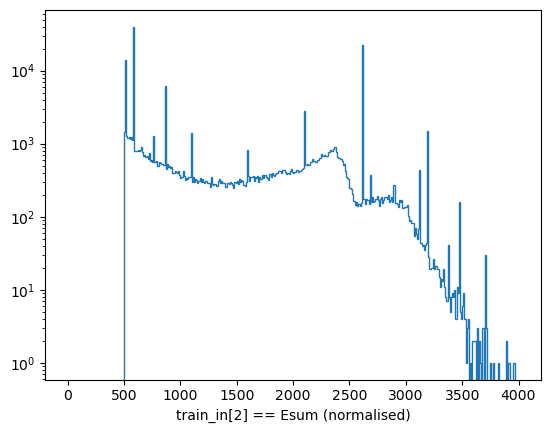

In [19]:
plt.figure()

_ = plt.hist(
    train_in[:, 2], range=(0,4000), bins=400, histtype='step'
)
plt.yscale('log')
plt.xlabel('train_in[2] == Esum (normalised)')


In [20]:
## Do a test train split
train_in_split, test_in, train_out_split, test_out = train_test_split(
    train_in,
    train_out,
    test_size=1/3,
    random_state=42
)

In [21]:
len(xdata), len(train_in), len(train_in_split), len(test_in) 

(193339, 193339, 128892, 64447)

In [22]:
# normalise output
input_dims  = len(train_in.T)
output_dims = len(train_out.T)

norm_info_in =[[0,1] for i in range(input_dims)]  # µ and stdev
norm_info_out=[[0,1] for i in range(output_dims)] # µ and stdev

train_in_norm = train_in_split.copy()
train_out_norm = train_out_split.copy()
test_in_norm = test_in.copy()
test_out_norm = test_out.copy()

for x in range(input_dims):
    norm_info_in[x] = [np.mean(train_in_split[:,x]), np.std(train_in_split[:,x])]
    train_in_norm[:,x]=(train_in_split[:,x]-np.mean(train_in_split[:,x]))/(np.std(train_in_split[:,x]))
    test_in_norm[:,x]=(test_in[:,x]-np.mean(train_in_split[:,x]))/(np.std(train_in_split[:,x]))

for x in range(output_dims):
    norm_info_out[x] = [np.mean(train_out_split[:,x]), np.std(train_out_split[:,x])]
    train_out_norm[:,x]=(train_out_split[:,x]-np.mean(train_out_split[:,x]))/(np.std(train_out_split[:,x]))
    test_out_norm[:,x]=(test_out[:,x]-np.mean(train_out_split[:,x]))/(np.std(train_out_split[:,x]))

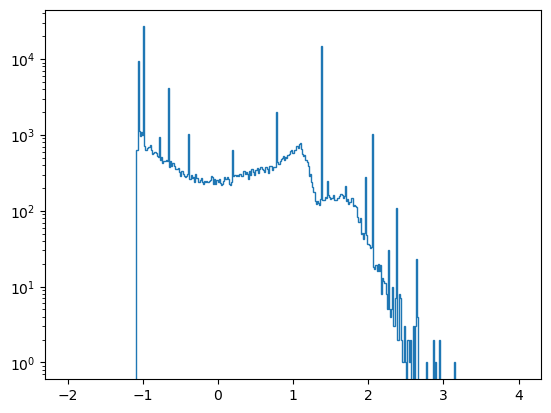

In [23]:
plt.figure()

_ = plt.hist(
    train_in_norm[:, 2], range=(-2,4), bins=400, histtype='step'
)
plt.yscale('log')


In [24]:
x_val, y_val = make_dataset(
    train_in_norm,          # input x
    train_out_norm,         # input y
    input_dims,             # x dims
    output_dims,            # y dims
    train_in_norm.shape[0]  # number of samples
) # examples


In [25]:
print(x_val.shape, y_val.shape)

(257784, 8) (257784, 1)


In [26]:
# in out case x_val should be twice as long a out training data
len(train_in_norm), len(x_val)

(128892, 257784)

In [27]:
x_val

array([[-0.75927689, -0.69846484, -1.02372881, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.80549327,  1.12908836,  1.0594778 , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.18256932,  0.74784157,  0.50662614, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.03485194,  2.22055367,  1.37862932, ...,  0.        ,
         1.        ,  1.37811213],
       [-0.56421579, -1.09266529, -0.96106592, ...,  0.        ,
         1.        , -0.96083633],
       [-0.84754305, -0.40513345, -0.60473987, ...,  0.        ,
         1.        , -0.60462029]])

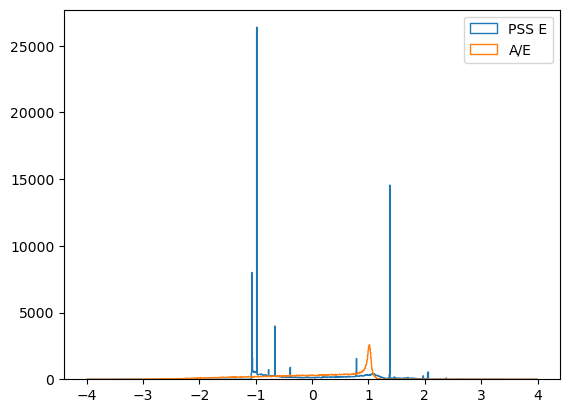

In [28]:
plt.figure()

_ = plt.hist(
    y_val[:len(train_in_norm)], range=(-4, 4), bins=1000, histtype='step', label='PSS E'
)
_ = plt.hist(
    y_val[len(train_in_norm):], range=(-4, 4), bins=1000, histtype='step', label='A/E'
)
plt.legend()

## Define the Model

Parameters to choose: (defaults taken from paper)
> hidden:    default=5,     Number of hidden layers   
> width:     default=50,    Width of the hidden layers  
> alpha:     default=0.2,   Slope for leaky relu  
> initialLR: default=0.001, Initial learning rate  
> batch:     default=512,   Batch size  
> cycles:    default=4,     Number of cylces to train for  
> epochs:    default=100,   Number of epochs in a cylce  
> patience:  default=100,   Number of epochs with no improvement before ending  

In [29]:
width       = 50
hidden      = 5
patience    = 100
cycles      = 4
initiallr   = 0.001
epochs      = 100
batch       = 512
normalise   = False
layer_output_dims = 5 if normalise else 1


In [30]:
if normalise:
    model = QuantileNet(network_type="normalizing")
else:
    model = QuantileNet(network_type="no normalizing")

model.add(
    tf.keras.layers.Dense(
        width,
        kernel_initializer="glorot_uniform",
        activation=None
    )
)
model.add(tf.keras.layers.LeakyReLU())#alpha=alpha))

for n in range(hidden - 1):
    model.add(
        tf.keras.layers.Dense(
            width,
            kernel_initializer="glorot_uniform",
            activation=None
        )
    )
    model.add(tf.keras.layers.LeakyReLU())#alpha=alpha))

model.add(
    tf.keras.layers.Dense(
        layer_output_dims,
        kernel_initializer="glorot_uniform",
        activation=None
    )
)

In [31]:
## Do another test train split for validation data
iqn_train_in, iqn_val_in, iqn_train_out, iqn_val_out = train_test_split(
    x_val,
    y_val,
    test_size=1/10,
    random_state=42
)

callbackMetric="val_loss"

callback = tf.keras.callbacks.EarlyStopping(
    monitor=callbackMetric,
    patience=patience,
    restore_best_weights=True
)

iqn_train_out = tf.expand_dims(iqn_train_out,1)
iqn_val_out = tf.expand_dims(iqn_val_out,1)

In [32]:
epoch_list=[]
train_loss_list=[]
val_loss_list=[]

for x in range(1):
    
    model.compile(
        # optimizer=tf.keras.optimizers.Adam(
        optimizer=tf.keras.optimizers.legacy.Adam(
            initiallr * (10**(-x)),
            amsgrad=False
        ),
        loss=model.loss,
        run_eagerly=False
    )

    history = model.fit(
        iqn_train_in,
        iqn_train_out,
        validation_data=(
            iqn_val_in,
            iqn_val_out
        ),
        epochs      = epochs,
        batch_size  = batch,
        verbose     = 2,
        callbacks   = [callback] #, callback2])
    )
    
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epoch_list.append(len(train_loss))
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    #Save the network
    model.save('emulator.keras')

epoch_list = range(1,sum(epoch_list)+1)
train_loss = np.concatenate(train_loss_list, axis=0)
val_loss = np.concatenate(val_loss_list, axis=0)

Epoch 1/100
454/454 - 5s - loss: 0.1233 - val_loss: 0.0963 - 5s/epoch - 10ms/step
Epoch 2/100
454/454 - 4s - loss: 0.0886 - val_loss: 0.0871 - 4s/epoch - 8ms/step
Epoch 3/100
454/454 - 4s - loss: 0.0844 - val_loss: 0.0819 - 4s/epoch - 9ms/step
Epoch 4/100
454/454 - 4s - loss: 0.0787 - val_loss: 0.0763 - 4s/epoch - 8ms/step
Epoch 5/100
454/454 - 4s - loss: 0.0721 - val_loss: 0.0687 - 4s/epoch - 8ms/step
Epoch 6/100
454/454 - 4s - loss: 0.0668 - val_loss: 0.0648 - 4s/epoch - 8ms/step
Epoch 7/100
454/454 - 4s - loss: 0.0633 - val_loss: 0.0623 - 4s/epoch - 8ms/step
Epoch 8/100
454/454 - 4s - loss: 0.0606 - val_loss: 0.0596 - 4s/epoch - 8ms/step
Epoch 9/100
454/454 - 4s - loss: 0.0601 - val_loss: 0.0597 - 4s/epoch - 8ms/step
Epoch 10/100
454/454 - 4s - loss: 0.0593 - val_loss: 0.0601 - 4s/epoch - 8ms/step
Epoch 11/100
454/454 - 4s - loss: 0.0581 - val_loss: 0.0579 - 4s/epoch - 8ms/step
Epoch 12/100
454/454 - 4s - loss: 0.0576 - val_loss: 0.0591 - 4s/epoch - 8ms/step
Epoch 13/100
454/454 - 3

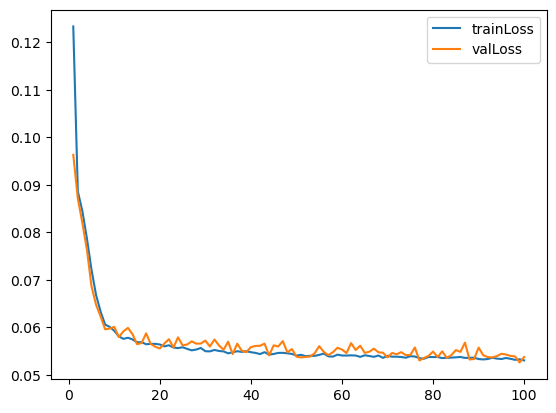

In [33]:
plt.figure()
plt.plot(epoch_list[:], train_loss[:], label="trainLoss")
plt.plot(epoch_list[:], val_loss[:], label="valLoss")
plt.legend()
# plt.savefig(networkname+"_loss_curve.png")

## Evaluate the trained model

In [34]:
x = [test_out_norm[:,0]]
y = [test_out_norm[:,1]]

# Make the correct input data for the IQN
in_val     = np.zeros(shape=np.array(x).shape)
test_data_set_y = np.concatenate([test_in_norm.T, in_val+1, in_val,   in_val, x], axis=0)
test_data_set_x = np.concatenate([test_in_norm.T, in_val,   in_val+1, x,      y], axis=0)
test_data_set  = np.concatenate([test_data_set_x, test_data_set_y], axis=1)


iqn_test_in = test_data_set[:-1,:].T
iqn_test_out = np.expand_dims(test_data_set[-1,:],1)

In [35]:
iqn_test_in.shape

(128894, 8)

In [36]:
model.evaluate(iqn_test_in, iqn_test_out, verbose=2, batch_size=128) #131072)

1007/1007 - 2s - loss: 0.0526 - 2s/epoch - 2ms/step


0.05261663720011711

## Start Sampling from the trained IQN

In [37]:
new_train_in = xdata.copy()
new_train_out = ydata.copy()

# new_train_out=(new_train_out+10)/(new_train_in+10) # not possible with different input and output dims

new_norm_info_in  = [[0,1] for i in range(input_dims)]
new_norm_info_out = [[0,1] for i in range(output_dims)]
new_train_in, new_test_in, new_train_out, new_test_out = train_test_split(
    new_train_in,
    new_train_out,
    test_size=1/3,
    random_state=42
)

new_test_in_norm = new_test_in.copy()
#Normalization 
for x in range(input_dims):
    new_norm_info_in[x]=[np.mean(new_train_in[:,x]),np.std(new_train_in[:,x])]
    new_test_in_norm[:,x]=(new_test_in[:,x]-np.mean(new_train_in[:,x]))/(np.std(new_train_in[:,x]))

for x in range(output_dims):
    new_norm_info_out[x]=[np.mean(new_train_out[:,x]),np.std(new_train_out[:,x])]

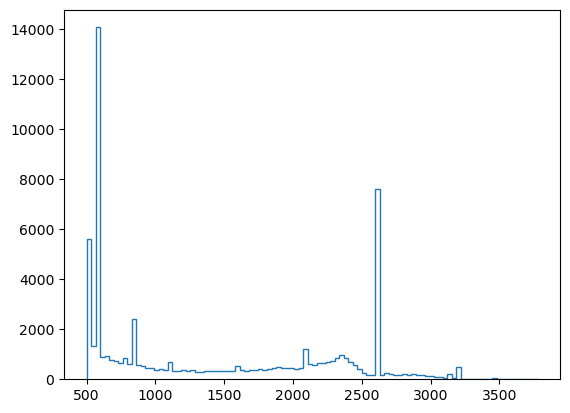

In [38]:
plt.figure()

_ = plt.hist(new_test_in[:,2], bins=100, histtype='step')


In [39]:
sample_num=1000
batch_size = 5000
ROW_SIZE = test_in_norm.shape[0]
NUM_COLUMNS = sample_num*output_dims

# The following is good for really large datasets but I can't get it
# to work on my computer
'''filename = 'emulator.h5'
f = tables.open_file(filename, mode='w')
atom = tables.Float32Atom()
all_data = f.create_earray(f.root, 'data', atom, (0, NUM_COLUMNS))'''

all_data = pd.DataFrame(columns=[f'col_{i}' for i in range(NUM_COLUMNS)], dtype=np.float32)
input_data = []

In [40]:
for y in range(0, new_test_in_norm.shape[0], batch_size):

    current_test_in = new_test_in_norm[y:min(y+batch_size, test_in.shape[0]),:]
    current_test_in = tf.transpose(current_test_in)
    current_test_in = tf.cast(current_test_in, tf.float32)

    out = sample_net(
        model, #Network
        sample_num, #Number of samples
        current_test_in, #Input
        current_test_in.shape[1], #Number of examples (batch size)
        current_test_in.shape[0], #5d input
        output_dims, #2d output
        network_type="not normalizing"
    ) 
    out = np.array(out)
    
    current_test_in = np.array(current_test_in).T

    for x in range(output_dims):
        out[:,:,x] = out[:,:,x]*norm_info_out[x][1]+norm_info_out[x][0]
        current_test_in[:,x] = current_test_in[:,x]*norm_info_in[x][1]+norm_info_in[x][0]

    input_data.append(new_test_in[y:min(y+batch_size, test_in.shape[0]),2])
    out = out.reshape(out.shape[0], out.shape[1]*out.shape[2])

    out_df = pd.DataFrame(out, columns=[f'col_{i}' for i in range(out.shape[1])])
    # print(out_df.shape)
    all_data = pd.concat([all_data, out_df], ignore_index=True)

    percent_done=min(y+batch_size, test_in_norm.shape[0])*100/test_in_norm.shape[0]
    percent_done=round(percent_done,4)

    print("Processing is " + str(percent_done)+"% done")

Processing is 7.7583% done
Processing is 15.5166% done
Processing is 23.2749% done
Processing is 31.0333% done
Processing is 38.7916% done
Processing is 46.5499% done
Processing is 54.3082% done
Processing is 62.0665% done
Processing is 69.8248% done
Processing is 77.5831% done
Processing is 85.3414% done
Processing is 93.0998% done
Processing is 100.0% done


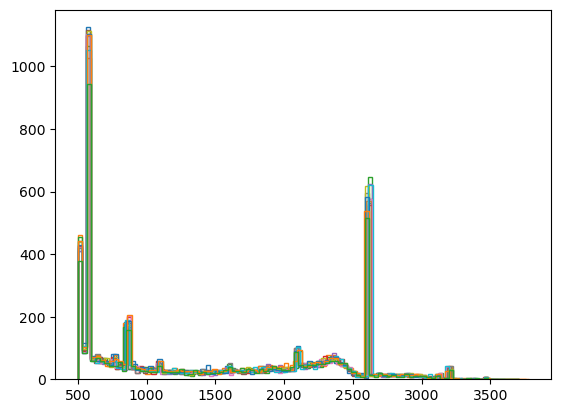

In [41]:
plt.figure()

for i in range(len(input_data)):
    _ = plt.hist(input_data[i], bins=100, histtype='step')


In [42]:
all_data

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_1990,col_1991,col_1992,col_1993,col_1994,col_1995,col_1996,col_1997,col_1998,col_1999
0,1133.072510,0.819860,1133.648071,0.817577,1131.192383,0.815587,1133.969482,0.814029,1133.908203,0.810541,...,1130.553589,0.819127,1131.144287,0.809720,1134.277466,0.819586,1130.560913,0.805385,1134.352661,0.806503
1,2726.221924,0.729444,2722.609375,0.788965,2724.609375,0.757504,2725.293457,0.777679,2725.405029,0.761194,...,2722.452637,0.763781,2725.430908,0.726881,2725.444336,0.787276,2721.560059,0.771250,2725.158447,0.798001
2,1712.316772,0.811870,1710.322388,0.810774,1717.255981,0.812780,1716.472656,0.810679,1711.287842,0.815675,...,1710.929565,0.805937,1711.072510,0.810347,1713.733398,0.819139,1716.195923,0.810089,1716.559448,0.811408
3,587.389404,0.651951,587.498352,0.792980,587.731018,0.582712,586.243408,0.780232,585.700256,0.532207,...,586.656738,0.685526,588.923279,0.616817,586.445312,0.651621,585.462524,0.546163,586.841187,0.632460
4,587.854919,0.812311,589.648438,0.813557,583.389893,0.804645,587.374634,0.823097,590.949463,0.819466,...,586.360840,0.809079,585.301758,0.799391,585.597656,0.794093,582.517822,0.814476,587.172241,0.803564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64442,629.558533,0.807925,633.554443,0.798418,629.196777,0.798392,630.115967,0.770458,630.239319,0.782637,...,631.847961,0.775549,630.153809,0.802953,629.300110,0.798832,631.547424,0.792856,632.704224,0.806727
64443,2607.509766,0.623712,2604.730469,0.575436,2609.457275,0.525371,2604.933105,0.512838,2606.893066,0.559004,...,2601.325195,0.622557,2607.042969,0.741561,2605.712891,0.619272,2610.426270,0.602846,2608.103027,0.709103
64444,623.601379,0.593390,625.787170,0.524157,625.559143,0.498603,625.808411,0.550205,629.509399,0.556157,...,623.789978,0.578986,625.624451,0.607061,625.429077,0.660263,624.547241,0.606633,624.444336,0.497547
64445,3197.786133,0.625548,3191.845215,0.484164,3190.829834,0.635763,3193.997070,0.381094,3193.384033,0.528667,...,3192.016602,0.532446,3182.519531,0.638400,3187.664551,0.527172,3192.747070,0.398454,3199.381836,0.457783


In [43]:
len(test_out)

64447

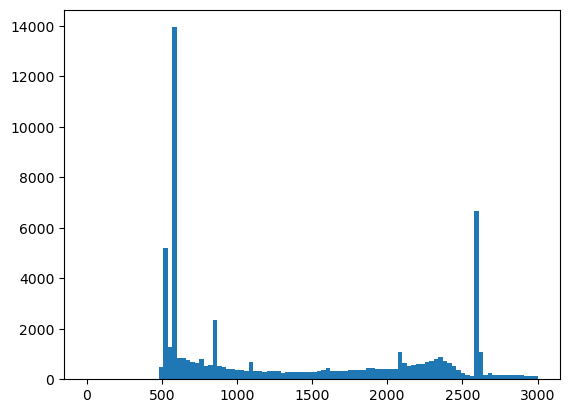

In [44]:
plt.figure()

_ = plt.hist(all_data.col_1990, range=(0,3000), bins=100)

In [45]:
input_data[2][0], input_data[1][0]

(2614.5043539694, 944.4300813901)

In [46]:
fep_vals = []
nfep = 0
dep_vals = []
ndep = 0
sep_vals = []
nsep = 0
for i in range(len(input_data)):
    for j in range(len(input_data[i])):
        index = i*1000 + j
        E = input_data[i][j]

        E_diff_fep = E - 2615
        E_diff_dep = E - 2615 + 1022
        E_diff_sep = E - 2615 + 511

        if abs(E_diff_fep) < 5 :
            nfep += 1
            for k, col in enumerate(all_data.columns):
                if k % 2:
                    val = all_data[col].loc[index]
                    fep_vals.append(val)
        
        if abs(E_diff_dep) < 5 :
            ndep += 1
            for k, col in enumerate(all_data.columns):
                if k % 2:
                    val = all_data[col].loc[index]
                    dep_vals.append(val)

        if abs(E_diff_sep) < 5 :
            nsep += 1
            for k, col in enumerate(all_data.columns):
                if k % 2:
                    val = all_data[col].loc[index]
                    sep_vals.append(val)

Text(0, 0.5, 'pdf')

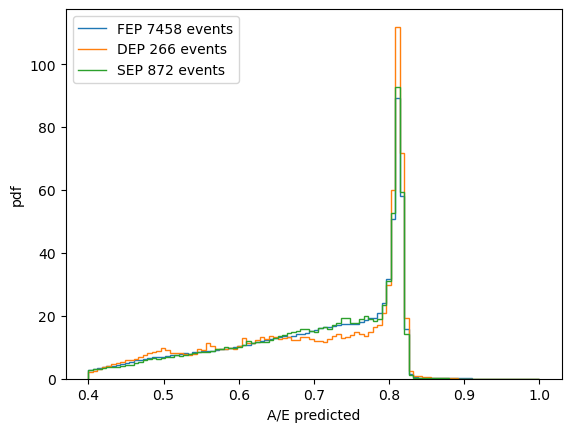

In [47]:
plt.figure()

freq, bin_edges = np.histogram(fep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/nfep, bin_edges, label=f'FEP {nfep} events')

freq, bin_edges = np.histogram(dep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/ndep, bin_edges, label=f'DEP {ndep} events')

freq, bin_edges = np.histogram(sep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/nsep, bin_edges, label=f'SEP {nsep} events')

plt.legend()

# plt.yscale('log')
plt.xlabel('A/E predicted')
plt.ylabel('pdf')

Text(0, 0.5, 'pdf')

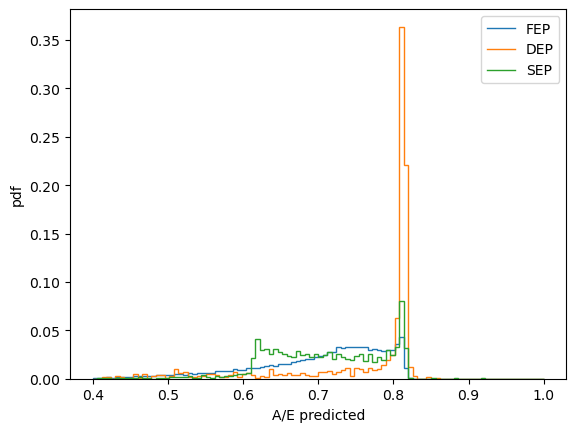

In [48]:
plt.figure()

all_fep_vals = []
all_dep_vals = []
all_sep_vals = []
for i in range(len(train_in)):
    E_true = train_in[i][2]
    AoE = train_out[i][1]
    E_diff = E_true - 2615
    if abs(E_diff) < 10:
        all_fep_vals.append(AoE)

    E_diff = E_true - 2615 + 511 + 511
    if abs(E_diff) < 10:
        all_dep_vals.append(AoE)

    E_diff = E_true - 2615 + 511
    if abs(E_diff) < 10:
        all_sep_vals.append(AoE)

freq, bin_edges = np.histogram(all_fep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/sum(freq), bin_edges, label='FEP')
freq, bin_edges = np.histogram(all_dep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/sum(freq), bin_edges, label='DEP')
freq, bin_edges = np.histogram(all_sep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/sum(freq), bin_edges, label='SEP')

plt.legend()

# plt.yscale('log')
plt.xlabel('A/E predicted')
plt.ylabel('pdf')

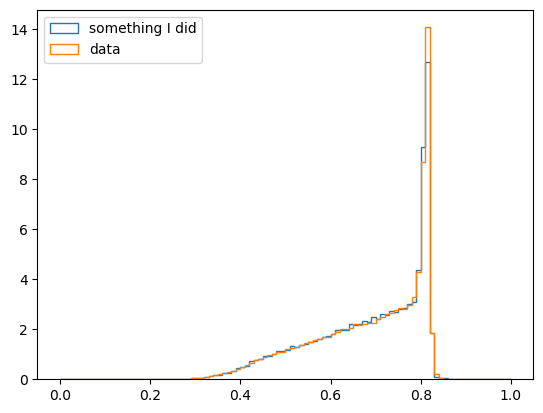

In [49]:
plt.figure()

_ = plt.hist(all_data.col_1991, range=(0,1), bins=100, histtype='step', density=True, label='something I did')
_ = plt.hist(df_data.AoEs, range=(0,1), bins=100, histtype='step', density=True, label='data')

plt.legend()

In [50]:
_, data, _, _ = train_test_split(df_data, df_data,test_size=1/3, random_state=42)

def calc_quant(data, vals):
    n = data.shape[1]
    left = np.count_nonzero(vals < data, axis=1)
    right = np.count_nonzero(vals <= data, axis=1)
    pct = (right + left + np.where(right>left, 1+0*right, 0*right)) /(2*n)
    return pct

batch_size=5000
num_samples = 1000
bins=100

In [81]:
columns = ['Column1', 'Column2']
total_samples = data.shape[0]

# Pre-allocate full arrays
median_predictions = np.empty((total_samples, output_dims), dtype=np.float32)
mean_predictions = np.empty((total_samples, output_dims), dtype=np.float32)
quantile_errors = np.empty((total_samples, output_dims), dtype=np.float32)

for x in range(total_samples//batch_size+1):
    start = x * batch_size
    end = min((x + 1) * batch_size, total_samples)
    actual_batch_size = end - start
    
    # Extract the batch from the DataFrame
    batch_data = all_data.iloc[start:end]

    # Convert DataFrame to NumPy array
    data_array = batch_data.to_numpy()
    reshaped_data = data_array.reshape(actual_batch_size, 1000, output_dims)
    true_data = new_test_out[x*batch_size:min((x + 1) * batch_size, total_samples), :]

    n = 100
    for y in range(output_dims):
        _sample = reshaped_data[:,:,y]
        true_val = true_data[:,y:y+1] # This order is in the file - not sure why they are named this way
        # pred_val = reshaped_data[:,:,y].T
        # true_val = true_data[:,y:y+1]
        quants = calc_quant(_sample, true_val)
        medians = np.median(_sample, axis=1)
        means = np.mean(_sample, axis=1)

        print(_sample.shape, medians)

        quantile_errors[start:end, y] = quants
        median_predictions[start:end, y] = medians
        mean_predictions[start:end, y] = means
    
    print(str(100*min((x+1)*batch_size, total_samples)/total_samples)+"% done")

(5000, 1000) [1131.7875  2725.335   1714.322   ...  595.10925 1240.1707  1509.8638 ]
(5000, 1000) [0.8126311  0.7637304  0.81185675 ... 0.66045153 0.8127913  0.79348266]
7.7583130324142315% done
(5000, 1000) [ 943.1349   517.45764 2607.276   ... 1110.4135  2351.0068  2351.565  ]
(5000, 1000) [0.7217285  0.81187886 0.69638497 ... 0.47536483 0.81306005 0.81082755]
15.516626064828463% done
(5000, 1000) [2608.0852  2129.0293   587.22504 ... 1593.5403  2332.4885  2394.1707 ]
(5000, 1000) [0.8032081  0.6925905  0.67256427 ... 0.80443937 0.53716075 0.7073221 ]
23.274939097242697% done
(5000, 1000) [ 622.44836 2610.1318  2941.2922  ... 2884.1885   841.02106 1828.0808 ]
(5000, 1000) [0.5013257  0.56137735 0.64319944 ... 0.7193868  0.8127308  0.81231654]
31.033252129656926% done
(5000, 1000) [2355.609   1723.2113   586.04956 ... 1228.1265   513.8417   587.3799 ]
(5000, 1000) [0.8132719  0.8110783  0.74963784 ... 0.8118744  0.43798596 0.6636024 ]
38.79156516207116% done
(5000, 1000) [ 586.77246 1

(array([475., 549., 422., 395., 465., 415., 407., 385., 441., 493.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

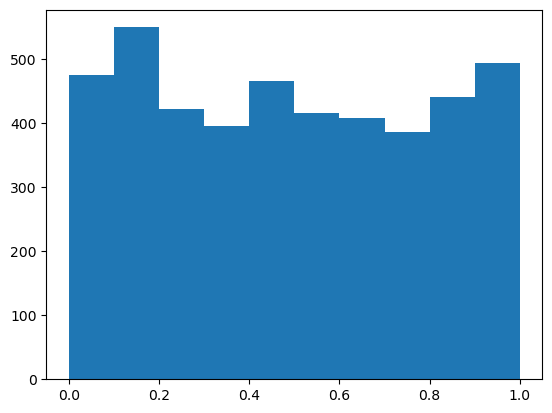

In [82]:
plt.hist(calc_quant(_sample, true_val))

In [83]:
weights = np.where(np.isnan(median_predictions), 0, 1) # 
medians = np.where(np.isnan(median_predictions), 0, median_predictions)
absolute_error_medians = new_test_out-medians
error_medians = absolute_error_medians/new_test_out

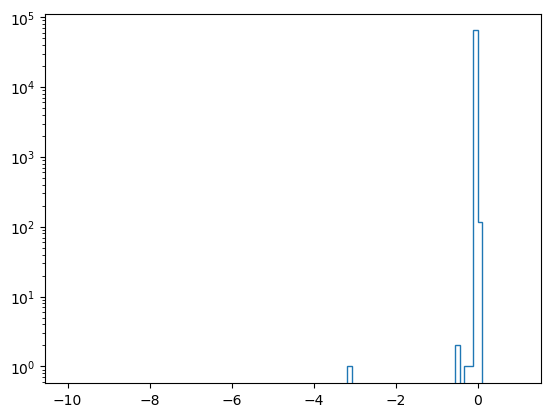

In [84]:
plt.figure()
plt.hist(error_medians[:,0], range=(-10,1), bins=100, histtype='step')
plt.yscale('log')


In [85]:
all_counts=[]
all_edges=[]
quant_counts=[]
quant_edges=[]
total_counts = 0
bins=50

ranges= [[0,3000],[0,1]]

for x in range(total_samples//batch_size+1):
    start = x * batch_size
    end = min((x + 1) * batch_size, total_samples)

    pred_counts=[]
    actual_batch_size = end-start

    temp_ydata = ydata[start:end,:]
    pred_data = all_data.to_numpy()[start:end,:]
    temp_xdata = xdata[start:end,:]
    quants = quantile_errors[start:end,:]
    
    weights = np.ones(temp_xdata[:,0].shape)
    total_counts+=np.sum(weights)

    for z in range(num_samples):
        current_data = pred_data[:,output_dims*z:output_dims*(z+1)]
        temp = []
        for y in range(output_dims):
            counts, _ = np.histogram(current_data[:,y], range=ranges[y], bins=bins, weights=weights)
            temp.append(counts)
        pred_counts.append(temp)
    pred_counts = np.array(pred_counts)

    for y in range(output_dims):
        #reco_counts, edges = np.histogram(recoData[:,y], range=ranges[y], bins=bins, weights=weights)
        true_counts, edges = np.histogram(temp_ydata[:,y], range=ranges[y], bins=bins, weights=weights)
        edges = edges[1:]/2+edges[:-1]/2
        q_counts, q_edges = np.histogram(quants[:,y], range=(0,1), bins=bins, weights=weights)
        q_edges = q_edges[1:]

        if(x==0):
            # all_counts.append([reco_counts, pred_counts[:,y,:], gen_counts])
            all_counts.append([pred_counts[:,y,:], true_counts])
            all_edges.append(edges)
            quant_counts.append([q_counts])
            quant_edges.append(q_edges)
        else:
            # all_counts[y][0]+=reco_counts
            all_counts[y][0]+=pred_counts[:,y,:]
            all_counts[y][1]+=true_counts
            quant_counts[y] +=q_counts

print("Total counts", total_counts)    
print("Total samples", total_samples) 

Total counts 64447.0
Total samples 64447


In [86]:
q_counts

array([193.,  58.,  61.,  73.,  90., 106., 126., 123., 101.,  93.,  86.,
        86.,  87.,  68.,  91.,  81.,  77.,  72.,  80.,  89., 105.,  73.,
        96.,  90., 101.,  89.,  87.,  96.,  70.,  72.,  82.,  97.,  92.,
        61.,  73.,  72.,  88.,  78.,  74.,  76.,  70.,  85.,  95.,  93.,
        98.,  95.,  85.,  70.,  50., 193.])

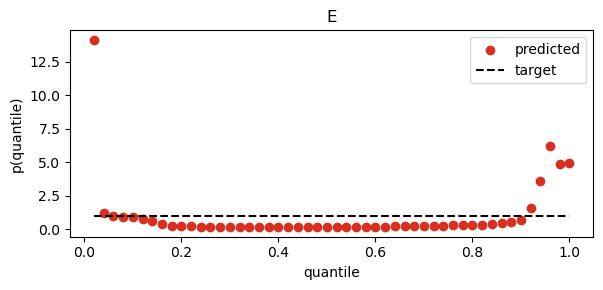

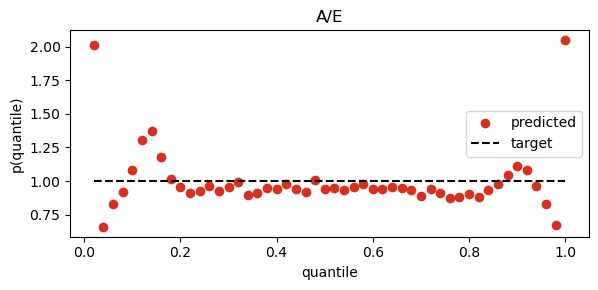

In [87]:
labels=["E", "A/E"]
titles=["E", "A/E"]
for x in range(output_dims):
    q_sums = [quant_counts[x][0,0]]
    for y in range(1, len(q_counts)):
        q_sums.append(q_sums[-1]+quant_counts[x][0,y])
    fig, (ax1) = plt.subplots(1, 1, figsize=(6,3))#, gridspec_kw={'height_ratios': [0.5, 1]})
    ax1.scatter(q_edges, bins*quant_counts[x][0,:]/np.sum(quant_counts[x][0,:]), c="#d7301f", label="predicted")
    ax1.plot(q_edges, q_edges*0+1, c="k", linestyle="--", label="target")
    # ax1.set_ylim((0.7,1.3))
    ax1.set_ylabel("p(quantile)")
    ax1.set_xlabel("quantile")
    ax1.set_title(labels[x])
    ax1.legend()
    plt.tight_layout()
    fig.subplots_adjust(wspace=0.0, hspace=0.1)

In [88]:
pred50 = []
pred16 = []
pred84 = []
for x in range(output_dims):
    pred50.append(np.quantile(all_counts[x][0], 0.5, axis=0))
    pred16.append(np.quantile(all_counts[x][0], 0.16, axis=0))
    pred84.append(np.quantile(all_counts[x][0], 0.84, axis=0))

/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_73620/985581516.py:15: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(all_edges[x], all_counts[x][1]/all_counts[x][1], color="k", marker="o",facecolors="none", s=5, linewidth=0.5)
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_73620/985581516.py:17: RuntimeWarning: divide by zero encountered in divide
  all_edges[x], pred50[x]/all_counts[x][1],
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_73620/985581516.py:17: RuntimeWarning: invalid value encountered in divide
  all_edges[x], pred50[x]/all_counts[x][1],
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_73620/985581516.py:18: RuntimeWarning: divide by zero encountered in divide
  xerr=0, yerr=[pred50[x]/all_counts[x][1]- pred16[x]/all_counts[x][1], pred84[x]/all_counts[x][1]-pred50[x]/all_counts[x][1]],
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_73620/985581516.py:18: RuntimeWarning: invalid value encountere

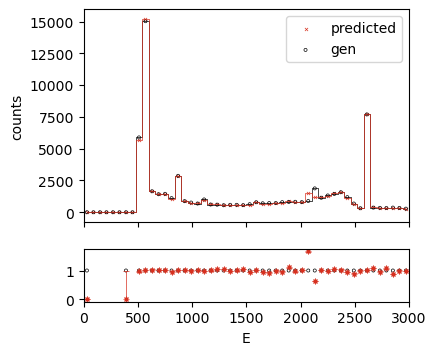

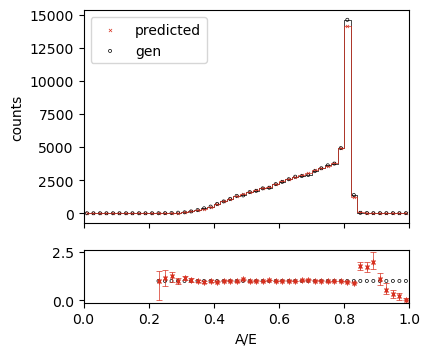

In [89]:
for x in range(output_dims):      
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.5*3/2.5,3.8), gridspec_kw={'height_ratios': [2,0.5]})
    
    ax1.step(all_edges[x], all_counts[x][1], where="mid", color="k", linewidth=0.5)#, linestyle="-.")
    ax1.step(all_edges[x], pred50[x], where="mid", color="#d7301f", linewidth=0.5)
    ax1.scatter(all_edges[x], pred50[x], label="predicted", color="#d7301f", marker="x", s=5, linewidth=0.5)
    ax1.scatter(all_edges[x], all_counts[x][1], label="gen",  color="k",facecolors='none', marker="o", s=5, linewidth=0.5)
    
    ax1.set_xlim(ranges[x])
    # ax1.set_ylim(0, max(all_counts[x][0])*1.1)
    ax1.set_ylabel("counts")
    ax1.set_xticklabels([])
    ax1.legend()
    
    ax2.scatter(all_edges[x], all_counts[x][1]/all_counts[x][1], color="k", marker="o",facecolors="none", s=5, linewidth=0.5)
    ax2.errorbar(
        all_edges[x], pred50[x]/all_counts[x][1],
        xerr=0, yerr=[pred50[x]/all_counts[x][1]- pred16[x]/all_counts[x][1], pred84[x]/all_counts[x][1]-pred50[x]/all_counts[x][1]],
        color="#d7301f", ls="",
        capsize=2,capthick=0.5, marker="x", linewidth=0.5, markersize=np.sqrt(5)
    )

    ax2.set_xlabel(labels[x])
    #ax2.set_ylabel(r"$\frac{\textnormal{predicted}}{\textnormal{gen}}$")
    # ax2.set_ylim((0.9,1.1))
    ax2.set_xlim(ranges[x])
    
    # plt.tight_layout()
    #fig.subplots_adjust(wspace=0.0, hspace=0.1)

(5, 6444700) (2, 6444700) (1, 6444700) (1, 6444700)


2025-06-30 20:03:23.853920: I external/local_xla/xla/service/service.cc:168] XLA service 0x30ef0a360 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-06-30 20:03:23.853941: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2025-06-30 20:03:23.897914: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751310204.170928 23636472 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-06-30 20:03:24.174351: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.


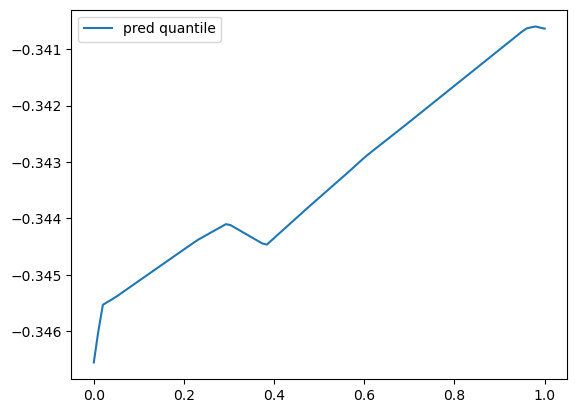

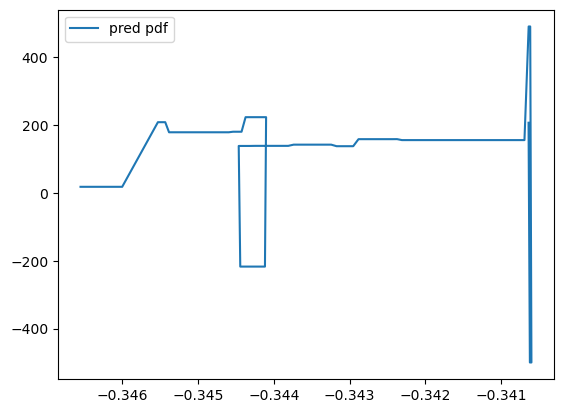

In [60]:
# Generate pdf and cdf for 10,000 quantiles between 0 and 1
quants = tf.cast(np.linspace(0, 1, 100), tf.float32)
cdf, pdf, quantiles = predict_dist(
    model,  # Model object
    quants,    # Quantiles to sample at
    tf.transpose(tf.cast(new_test_in_norm, tf.float32)),  # Input examples
    tf.transpose(tf.cast(new_test_in_norm, tf.float32)).shape[1],  # Number of input examples
    0,  # Current sampling dim
    tf.transpose(tf.cast(new_test_in_norm, tf.float32)).shape[0],  # Input dim
    2, # Output dim
    network_type='no normalizing'
) 

# pdf, cdf, and quantile function for 1st dimension
plt.plot(quantiles, cdf[0, :], label="pred quantile")
# plt.plot(cdf[0, :], quantiles, label="pred cdf")
plt.legend()

plt.figure()
plt.plot(cdf[0, :], pdf[0, :], label="pred pdf")
plt.legend()


In [61]:

# Generate pdf and cdf for 10,000 quantiles between 0 and 1
quants = tf.cast(np.linspace(0, 1, 10), tf.float32)
cdf, pdf, quantiles = predict_dist(
    model,  # Model object
    quants,    # Quantiles to sample at
    tf.transpose(current_test_in),  # Input examples
    tf.transpose(current_test_in).shape[1],  # Number of input examples
    1,  # Current sampling dim
    tf.transpose(current_test_in).shape[0],  # Input dim
    2, # Output dim
    previous_samples=tf.transpose(current_test_in),
    network_type='no normalizing'
) 

# pdf, cdf, and quantile function for 1st dimension
plt.plot(quantiles, cdf[0, :], label="pred quantile")
plt.plot(cdf[0, :], quantiles, label="pred cdf")
plt.legend()

plt.figure()
plt.plot(cdf[0, :], pdf[0, :], label="pred pdf")
plt.legend()


ValueError: in user code:

    File "/Users/williamquinn/Documents/legend/emulator/gem/PSDEmulatorIQN/tensor_flow/quantile_network.py", line 710, in predict_no_normalizing  *
        val = layer(val)
    File "/Users/williamquinn/anaconda3/envs/tfenv/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "/Users/williamquinn/anaconda3/envs/tfenv/lib/python3.11/site-packages/keras/src/engine/input_spec.py", line 280, in assert_input_compatibility
        raise ValueError(

    ValueError: Input 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 9, but received input with shape (44470, 13)
